In [1]:
import numpy as np
import pandas as pd
import os


In [2]:
import sys
print(sys.executable)

C:\Program Files\Python311\python.exe


In [3]:
os.chdir(r'C:\Users\LENOVO\Desktop\Machine_learning_projects\sms spam classifier')

In [4]:
df=pd.read_csv('spam.csv',encoding='latin-1')

In [5]:
df.sample(5)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
4739,ham,"I keep seeing weird shit and bein all \woah\"" ...",NaN,NaN,NaN
5065,ham,I calls you later. Afternoon onwords mtnl serv...,NaN,NaN,NaN
2116,ham,"It's that time of the week again, ryan",NaN,NaN,NaN
5414,ham,East coast,NaN,NaN,NaN
3393,ham,Bull. Your plan was to go floating off to IKEA...,NaN,NaN,NaN


In [6]:
df.shape

(5572, 5)

#1.Data cleaning
#2.EDA
#3.Text preprocessing
#4.Model building
#5.Evaluation
#6.Improvements
#7.Website
#8.Deploy


#1.Data cleaning

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   v1          5572 non-null   str  
 1   v2          5572 non-null   str  
 2   Unnamed: 2  50 non-null     str  
 3   Unnamed: 3  12 non-null     str  
 4   Unnamed: 4  6 non-null      str  
dtypes: str(5)
memory usage: 677.1 KB


In [8]:
#drop last 3 cols
# df.drop(columns=['Unnamed: 2','Unnamed: 3','Unnamed: 4'],inplace=True)

In [9]:
df.sample(5)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
3587,ham,If you were/are free i can give. Otherwise nal...,NaN,NaN,NaN
4519,ham,What to think no one saying clearly. Ok leave ...,NaN,NaN,NaN
2980,ham,7 wonders in My WORLD 7th You 6th Ur style 5th...,NaN,NaN,NaN
430,ham,At home watching tv lor.,NaN,NaN,NaN
4937,ham,No it was cancelled yeah baby! Well that sound...,NaN,NaN,NaN


In [10]:
#renaming the cols
df.rename(columns={'v1':'target','v2':'text'},inplace=True)
df.sample(5)

,target,text,Unnamed: 2,Unnamed: 3,Unnamed: 4
5258,ham,1 in cbe. 2 in chennai.,NaN,NaN,NaN
1063,spam,We have new local dates in your area - Lots of...,NaN,NaN,NaN
1433,ham,You intrepid duo you! Have a great time and se...,NaN,NaN,NaN
1240,ham,Oh yes I can speak txt 2 u no! Hmm. Did u get ...,NaN,NaN,NaN
3432,ham,Christmas is An occasion that is Celebrated as...,NaN,NaN,NaN


In [11]:
from sklearn.preprocessing import LabelEncoder
encoder=LabelEncoder()


In [12]:
df['target'] = encoder.fit_transform(df['target'])


In [13]:
df.head()

,target,text,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,0,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,0,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,0,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,0,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [14]:
# import sklearn
# print(sklearn.__version__)

In [15]:
#missing value
df.isnull().sum()

target           0
text             0
Unnamed: 2    5522
Unnamed: 3    5560
Unnamed: 4    5566
dtype: int64

In [16]:
#check for duplicated value
df.duplicated().sum()

np.int64(403)

In [17]:
#remove duplicates
print(f"Duplicates found: {df.duplicated().sum()}")
df=df.drop_duplicates(keep='first')


Duplicates found: 403


In [18]:
df.duplicated().sum()

np.int64(0)

In [19]:
df.shape

(5169, 5)

#2.EDA

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

In [21]:
df.head()

,target,text,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,0,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,0,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,0,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,0,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [22]:
df['target'].value_counts()

target
0    4516
1     653
Name: count, dtype: int64

In [113]:
# Check 1: class balance
print(df['target'].value_counts())

# Check 2: test with a known spam message directly
test_msg = "Congratulations! You've won a free prize. Call now to claim!"
transformed = transform_text(test_msg)
print("\nTransformed:", transformed)

vec = tfidf.transform([transformed])
pred = mnb.predict(vec)
proba = mnb.predict_proba(vec)

print("Prediction:", "SPAM" if pred[0]==1 else "NOT SPAM")
print("Probabilities [ham, spam]:", proba)

target
0    4516
1     653
Name: count, dtype: int64

Transformed: congratul free prize call claim
Prediction: SPAM
Probabilities [ham, spam]: [[0.03902731 0.96097269]]


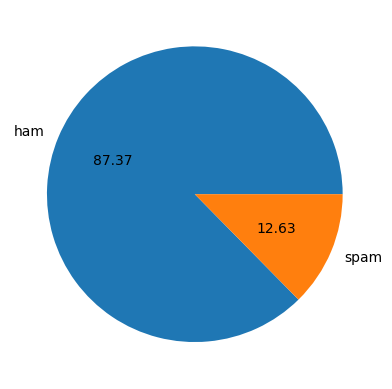

In [23]:
# import matplotlib.pyplot as plt
plt.pie(df['target'].value_counts(),labels=['ham','spam'],autopct="%0.2f")
plt.show()

In [24]:
#Data is imbalanced


In [25]:
import nltk

In [26]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\LENOVO\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [27]:
df['num_characters']=df['text'].apply(len)

In [28]:
df.head()

,target,text,Unnamed: 2,Unnamed: 3,Unnamed: 4,num_characters
0,0,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN,111
1,0,Ok lar... Joking wif u oni...,NaN,NaN,NaN,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN,155
3,0,U dun say so early hor... U c already then say...,NaN,NaN,NaN,49
4,0,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN,61


In [29]:
#num of words
df['num_words']=df['text'].apply(lambda x:len(nltk.word_tokenize(x)))


In [30]:
df.head()

,target,text,Unnamed: 2,Unnamed: 3,Unnamed: 4,num_characters,num_words
0,0,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN,111,24
1,0,Ok lar... Joking wif u oni...,NaN,NaN,NaN,29,8
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN,155,37
3,0,U dun say so early hor... U c already then say...,NaN,NaN,NaN,49,13
4,0,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN,61,15


In [31]:
df['num_sentences']=df['text'].apply(lambda x:len(nltk.sent_tokenize(x)))


In [32]:
df.head()

,target,text,Unnamed: 2,Unnamed: 3,Unnamed: 4,num_characters,num_words,num_sentences
0,0,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN,111,24,2
1,0,Ok lar... Joking wif u oni...,NaN,NaN,NaN,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN,155,37,2
3,0,U dun say so early hor... U c already then say...,NaN,NaN,NaN,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN,61,15,1


In [33]:
df[['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.455794,1.965564
std,58.236293,13.324758,1.448541
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


In [34]:
df[df['target'] == 0][['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.123782,1.820195
std,56.358207,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [35]:
df[df['target'] == 1][['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.970904
std,30.137753,7.008418,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


<Axes: xlabel='num_characters', ylabel='Count'>

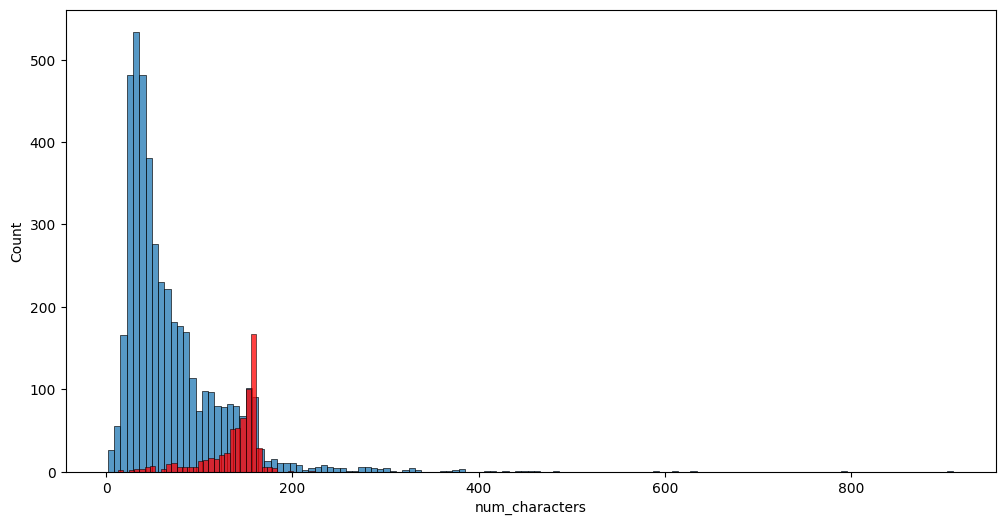

In [36]:
plt.figure(figsize=(12,6))
sns.histplot(df[df['target'] == 0]['num_characters'])
sns.histplot(df[df['target'] == 1]['num_characters'], color='red')

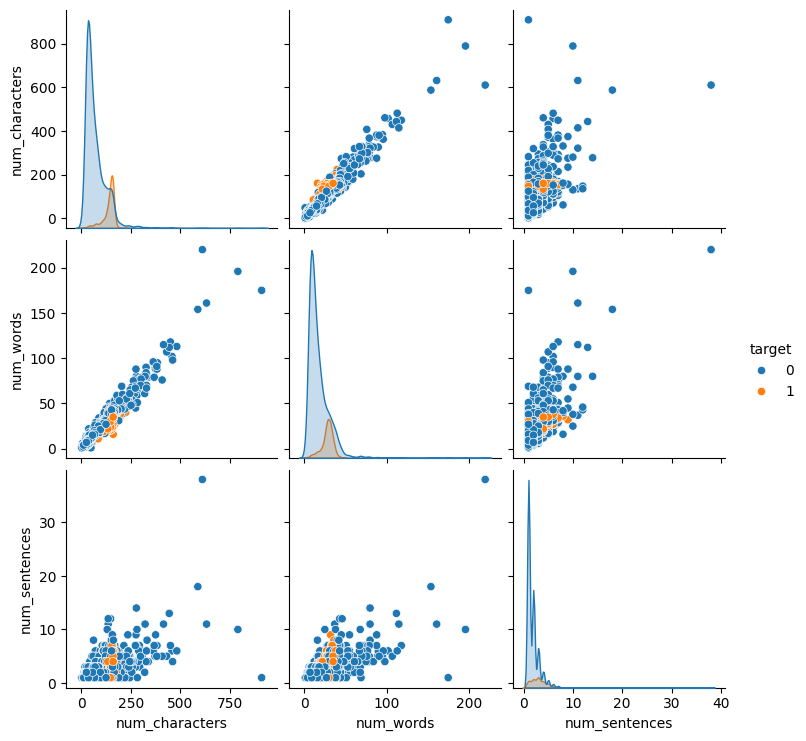

In [37]:
sns.pairplot(df,hue='target')

<Axes: >

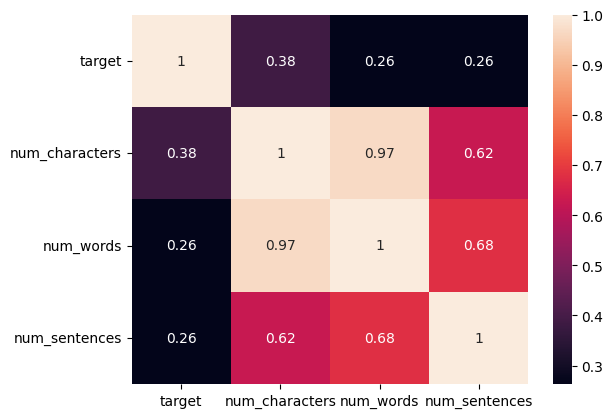

In [38]:
sns.heatmap(df.corr(numeric_only=True), annot=True)

Data preprocessing
 .lower case
 .Tokenization
 .Removing special characters
 .Removing stop words and punctuation
 .stemming

In [39]:
import string
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer

# You must define ps before the function can use it
ps = PorterStemmer()

In [40]:
def transform_text(text):
    text=text.lower()
    text=nltk.word_tokenize(text)

    y = []
    for i in text:
        if i.isalnum():
            y.append(i)

    text=y[:]
    y.clear()

    for i in text:
        if i not in stopwords.words('english') and i not in string.punctuation:
            y.append(i)

    text= y[:] 
    y.clear()

    for i in text:
        y.append(ps.stem(i))
        
    return " ".join(y)
    

In [41]:
transform_text('Hi how are you Prakriti?')

'hi prakriti'

In [42]:
transform_text('Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat')

'go jurong point crazi avail bugi n great world la e buffet cine got amor wat'

In [43]:
df['text'][0]

'Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...'

In [44]:
# from nltk.stem.porter import PorterStemmer

# ps= PorterStemmer()
ps.stem('Beauty')
ps.stem('Caring')

'care'

In [45]:
df['transformed_text']=df['text'].apply(transform_text)

In [46]:
df.head()

,target,text,Unnamed: 2,Unnamed: 3,Unnamed: 4,num_characters,num_words,num_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN,111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,NaN,NaN,NaN,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,NaN,NaN,NaN,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN,61,15,1,nah think goe usf live around though


In [47]:
from wordcloud import WordCloud
wc = WordCloud(width=500,height=500,min_font_size=10,background_color='white')

In [48]:
spam_wc = wc.generate(df[df['target'] == 1]['transformed_text'].str.cat(sep=" "))

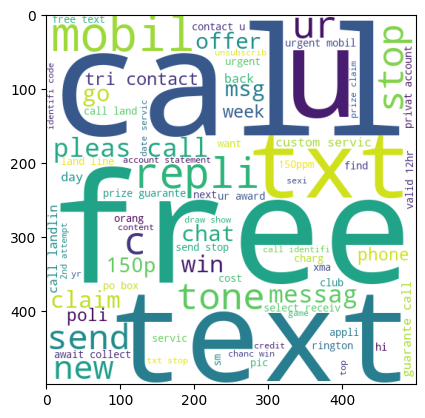

In [49]:
plt.imshow(spam_wc)

In [50]:
plt.show()

In [51]:
ham_wc = wc.generate(df[df['target'] == 0]['transformed_text'].str.cat(sep=" "))

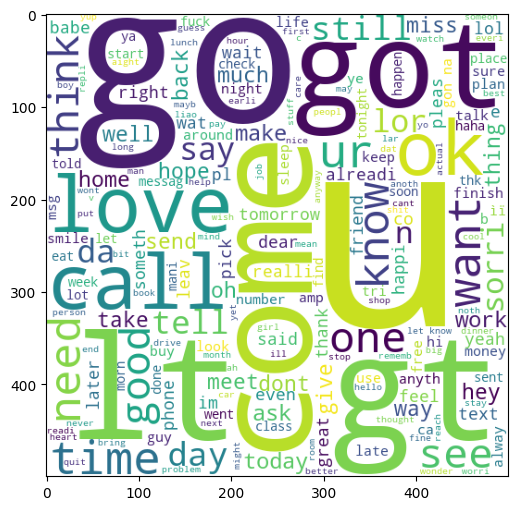

In [52]:
plt.figure(figsize=(15,6))
plt.imshow(ham_wc)

In [53]:
df.head()

,target,text,Unnamed: 2,Unnamed: 3,Unnamed: 4,num_characters,num_words,num_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN,111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,NaN,NaN,NaN,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,NaN,NaN,NaN,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN,61,15,1,nah think goe usf live around though


In [54]:
from collections import Counter

In [55]:
spam_corpus=[]
for msg in df[df['target'] == 1]['transformed_text'].tolist():
    for word in msg.split():
        spam_corpus.append(word)
  

In [56]:
print(len(spam_corpus))

9939


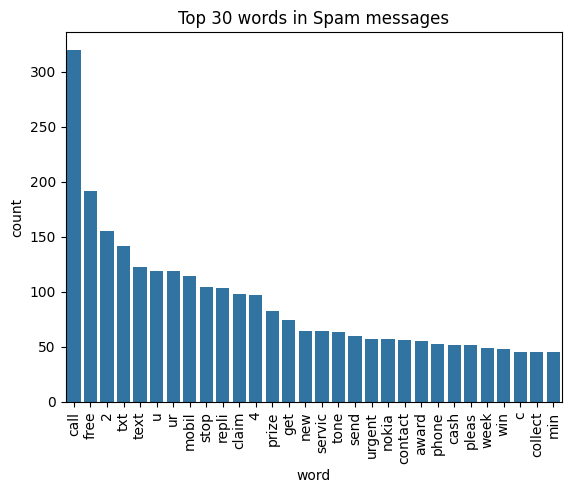

In [57]:
# from collections import Counter
spam_common = pd.DataFrame(Counter(spam_corpus).most_common(30), columns=['word','count'])
sns.barplot(data=spam_common, x='word', y='count')
# sns.barplot(x=pd.DataFrame(Counter(spam_corpus).most_common(30))[0],y=pd.DataFrame(Counter(spam_corpus).most_common(30))[1])
plt.xticks(rotation='vertical')
plt.title('Top 30 words in Spam messages')
plt.show()


In [58]:
ham_corpus=[]
for msg in df[df['target'] == 0]['transformed_text'].tolist():
    for word in msg.split():
        ham_corpus.append(word)
  

In [59]:
print(len(ham_corpus))

35404


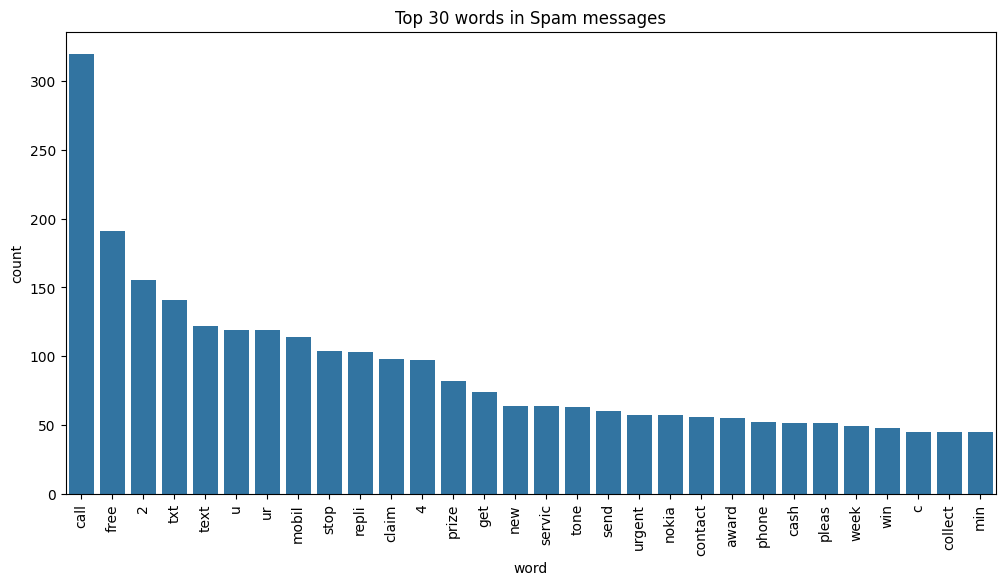

In [60]:
# from collections import Counter
ham_common = pd.DataFrame(Counter(ham_corpus).most_common(30), columns=['word','count'])
plt.figure(figsize=(12,6))
sns.barplot(data=spam_common, x='word', y='count')
# sns.barplot(x=pd.DataFrame(Counter(ham_corpus).most_common(30))[0],y=pd.DataFrame(Counter(ham_corpus).most_common(30))[1])
plt.xticks(rotation='vertical')
plt.title('Top 30 words in Spam messages')
plt.show()

4.Model Building

In [61]:
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer
cv = CountVectorizer()
tfidf=TfidfVectorizer(max_features=3000)

In [62]:
x= tfidf.fit_transform(df['transformed_text']).toarray()

In [63]:
# from sklearn.preprocessing import MinMaxScaler
# scaler=MinMaxScaler()
# x=scaler.fit_transform(x)

In [64]:
x=np.hstack((x,df['num_characters'].values.reshape(-1,1)))

In [65]:
x.shape

(5169, 3001)

In [66]:
y= df['target'].values

In [67]:
y

array([0, 0, 1, ..., 0, 0, 0], shape=(5169,))

In [68]:
from sklearn.model_selection import train_test_split

In [69]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=2)

In [70]:
from sklearn.naive_bayes import GaussianNB,MultinomialNB,BernoulliNB
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score

In [71]:
gnb=GaussianNB()
mnb=MultinomialNB()
bnb=BernoulliNB()

In [72]:
gnb.fit(x_train,y_train)
y_pred1 = gnb.predict(x_test)
print(accuracy_score(y_test,y_pred1))
print(confusion_matrix(y_test,y_pred1))
print(precision_score(y_test,y_pred1))



0.8936170212765957
[[808  88]
 [ 22 116]]
0.5686274509803921


In [73]:
mnb.fit(x_train,y_train)
y_pred2 = mnb.predict(x_test)
print(accuracy_score(y_test,y_pred2))
print(confusion_matrix(y_test,y_pred2))
print(precision_score(y_test,y_pred2))

0.9400386847195358
[[896   0]
 [ 62  76]]
1.0


In [74]:
bnb.fit(x_train,y_train)
y_pred3 = bnb.predict(x_test)
print(accuracy_score(y_test,y_pred3))
print(confusion_matrix(y_test,y_pred3))
print(precision_score(y_test,y_pred3))

0.9835589941972921
[[895   1]
 [ 16 122]]
0.991869918699187


In [75]:
#tfidf --> MNB

In [76]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble  import ExtraTreesClassifier 
from sklearn.ensemble  import GradientBoostingClassifier
from xgboost import XGBClassifier



In [77]:
svc=SVC(kernel='sigmoid',gamma=1.0)
knc=KNeighborsClassifier()
mnb=MultinomialNB()
dtc=DecisionTreeClassifier(max_depth=5)
lrc=LogisticRegression(solver='liblinear',penalty='l1')
rfc=RandomForestClassifier(n_estimators=50,random_state=2)
abc=AdaBoostClassifier(n_estimators=50,random_state=2)
bc=BaggingClassifier(n_estimators=50,random_state=2)
etc=ExtraTreesClassifier(n_estimators=50,random_state=2)
gbdt=GradientBoostingClassifier(n_estimators=50,random_state=2)
xgb=XGBClassifier(n_estimators=50,random_state=2)




In [78]:
clfs = {'SVC':svc,'KN':knc,'NB':mnb,'DT':dtc,'LR':lrc,'RF':rfc,'AdaBoost':abc,'BgC':bc,'ETC':etc,'GBDT':gbdt,'xgb':xgb} 

In [79]:
def train_classifier(clf,x_train,y_train,x_test,y_test):
    clf.fit(x_train,y_train)
    y_pred=clf.predict(x_test)
    accuracy=accuracy_score(y_test,y_pred)
    precision=precision_score(y_test,y_pred)

    return accuracy,precision
    

In [80]:
train_classifier(svc,x_train,y_train,x_test,y_test)

C:\Users\LENOVO\AppData\Roaming\Python\Python311\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


(0.8665377176015474, 0.0)

In [81]:
accuracy_scores= []
precision_scores= []

for name,clf in clfs.items():

    current_accuracy,current_precision=train_classifier(clf,x_train,y_train,x_test,y_test)

    print("For ",name)
    print("Accuracy - ",current_accuracy)
    print("Precision - ",current_precision)

    accuracy_scores.append(current_accuracy)
    precision_scores.append(current_precision)
    
    
    
    
    

C:\Users\LENOVO\AppData\Roaming\Python\Python311\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


For  SVC
Accuracy -  0.8665377176015474
Precision -  0.0
For  KN
Accuracy -  0.9342359767891683
Precision -  0.8431372549019608
For  NB
Accuracy -  0.9400386847195358
Precision -  1.0
For  DT
Accuracy -  0.9477756286266924
Precision -  0.8962264150943396


C:\Users\LENOVO\AppData\Roaming\Python\Python311\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\LENOVO\AppData\Roaming\Python\Python311\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


For  LR
Accuracy -  0.9593810444874274
Precision -  0.9528301886792453
For  RF
Accuracy -  0.9729206963249516
Precision -  0.9824561403508771
For  AdaBoost
Accuracy -  0.9448742746615088
Precision -  0.8932038834951457
For  BgC
Accuracy -  0.960348162475822
Precision -  0.8646616541353384
For  ETC
Accuracy -  0.9806576402321083
Precision -  0.9836065573770492
For  GBDT
Accuracy -  0.9506769825918762
Precision -  0.9306930693069307
For  xgb
Accuracy -  0.971953578336557
Precision -  0.943089430894309


In [82]:
performance_df=pd.DataFrame({'Algorithm':clfs.keys(),'Precision':accuracy_scores,'Precision':precision_scores})

In [83]:
performance_df

,Algorithm,Precision
0,SVC,0.000000
1,KN,0.843137
2,NB,1.000000
3,DT,0.896226
4,LR,0.952830
5,RF,0.982456
6,AdaBoost,0.893204
7,BgC,0.864662
8,ETC,0.983607
9,GBDT,0.930693


In [84]:
performance_df1=pd.melt(performance_df,id_vars="Algorithm")

In [85]:
performance_df1

,Algorithm,variable,value
0,SVC,Precision,0.000000
1,KN,Precision,0.843137
2,NB,Precision,1.000000
3,DT,Precision,0.896226
4,LR,Precision,0.952830
5,RF,Precision,0.982456
6,AdaBoost,Precision,0.893204
7,BgC,Precision,0.864662
8,ETC,Precision,0.983607
9,GBDT,Precision,0.930693


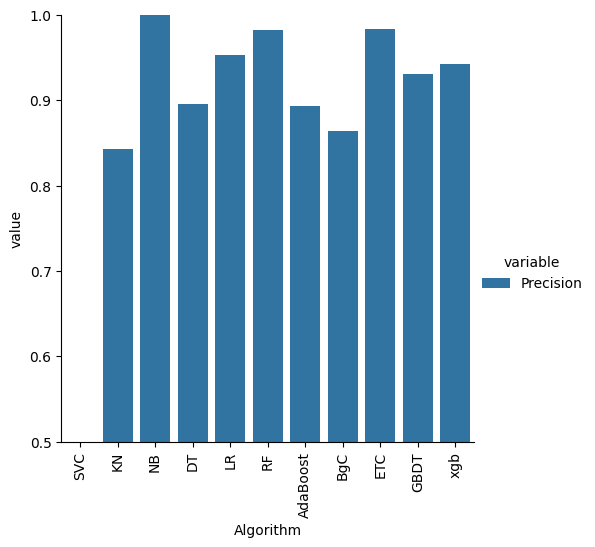

In [86]:
g=sns.catplot(x='Algorithm',y='value',hue='variable',data=performance_df1,kind='bar',height=5)
plt.ylim(0.5,1.0)
g.set_xticklabels(rotation=90)
plt.show()

In [87]:
#model improve
#1.change the max_features parameter of TfIdf

In [88]:
temp_df=pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy_max_ft_3000':accuracy_scores,'Precision_max_ft_3000':precision_scores})

In [89]:
temp_df=pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy_scaling':accuracy_scores,'Precision_scaling':precision_scores})

In [90]:
new_df=performance_df.merge(temp_df,on='Algorithm')

In [91]:
new_df_scaled=new_df.merge(temp_df,on='Algorithm')

In [92]:
new_df_scaled

,Algorithm,Precision,Accuracy_scaling_x,Precision_scaling_x,Accuracy_scaling_y,Precision_scaling_y
0,SVC,0.000000,0.866538,0.000000,0.866538,0.000000
1,KN,0.843137,0.934236,0.843137,0.934236,0.843137
2,NB,1.000000,0.940039,1.000000,0.940039,1.000000
3,DT,0.896226,0.947776,0.896226,0.947776,0.896226
4,LR,0.952830,0.959381,0.952830,0.959381,0.952830
5,RF,0.982456,0.972921,0.982456,0.972921,0.982456
6,AdaBoost,0.893204,0.944874,0.893204,0.944874,0.893204
7,BgC,0.864662,0.960348,0.864662,0.960348,0.864662
8,ETC,0.983607,0.980658,0.983607,0.980658,0.983607
9,GBDT,0.930693,0.950677,0.930693,0.950677,0.930693


In [93]:
#voting classifier
from sklearn.ensemble import VotingClassifier
svc=SVC(kernel='sigmoid',gamma=1.0,probability=True)
nmb=MultinomialNB()
etc=ExtraTreesClassifier(n_estimators=50,random_state=2)



In [94]:
voting=VotingClassifier(estimators=[('svm',svc),('nb',mnb),('et',etc)],voting='soft')

In [95]:
voting.fit(x_train,y_train)

,"estimators estimators: list of (str, estimator) tuplesInvoking the ``fit`` method on the ``VotingClassifier`` will fit clonesof those original estimators that will be stored in the class attribute``self.estimators_``. An estimator can be set to ``'drop'`` using:meth:`set_params`... versionchanged:: 0.21 ``'drop'`` is accepted. Using None was deprecated in 0.22 and support was removed in 0.24.","[('svm', ...), ('nb', ...), ...]"
,"voting voting: {'hard', 'soft'}, default='hard'If 'hard', uses predicted class labels for majority rule voting.Else if 'soft', predicts the class label based on the argmax ofthe sums of the predicted probabilities, which is recommended foran ensemble of well-calibrated classifiers.",'soft'
,"weights weights: array-like of shape (n_classifiers,), default=NoneSequence of weights (`float` or `int`) to weight the occurrences ofpredicted class labels (`hard` voting) or class probabilitiesbefore averaging (`soft` voting). Uses uniform weights if `None`.",None
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for ``fit``.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionadded:: 0.18",None
,"flatten_transform flatten_transform: bool, default=TrueAffects shape of transform output only when voting='soft'If voting='soft' and flatten_transform=True, transform method returnsmatrix with shape (n_samples, n_classifiers * n_classes). Ifflatten_transform=False, it returns(n_classifiers, n_samples, n_classes).",True
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting will be printed as itis completed... versionadded:: 0.23",False
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'sigmoid'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",1.0
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0


In [96]:
y_pred=voting.predict(x_test)
print("Accuracy",accuracy_score(y_test,y_pred))
print("Precision",precision_score(y_test,y_pred))

Accuracy 0.9429400386847195
Precision 1.0


In [97]:
#applying stacking
from sklearn.ensemble import StackingClassifier
estimators=[('svm',svc),('nb',mnb),('et',etc)]
final_estimator=RandomForestClassifier()

In [98]:
# from sklearn.ensemble import StackingClassifier

In [99]:
clf= StackingClassifier(estimators=estimators, final_estimator=final_estimator)

In [100]:
clf.fit(x_train,y_train)
y_pred=clf.predict(x_test)
print("Accuracy",accuracy_score(y_test,y_pred))
print("Precision",precision_score(y_test,y_pred))

Accuracy 0.9709864603481625
Precision 0.8857142857142857


In [101]:
import pickle
pickle.dump(tfidf,open('vectorizer.pkl','wb'))
pickle.dump(mnb,open('model.pkl','wb'))

In [102]:
import pickle
import os

# Force save to the correct folder
save_path = r'C:\Users\LENOVO\Desktop\Machine_learning_projects\sms spam classifier'

pickle.dump(tfidf, open(os.path.join(save_path, 'vectorizer.pkl'), 'wb'))
pickle.dump(mnb, open(os.path.join(save_path, 'model.pkl'), 'wb'))

print("Files saved to:", save_path)
print("Files in folder:", os.listdir(save_path))

Files saved to: C:\Users\LENOVO\Desktop\Machine_learning_projects\sms spam classifier
Files in folder: ['.idea', '.ipynb_checkpoints', '.venv', 'app.py', 'main.py', 'model.pkl', 'spam.csv', 'spamdetection.ipynb', 'vectorizer.pkl']


In [112]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
import pickle, os

X = df['transformed_text']  # raw text
y = df['target']             # labels

# Split (note: capital X_train, X_test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, 
                                                      random_state=42, 
                                                      stratify=y)

# Vectorize (capital X_train)
tfidf = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf.fit_transform(X_train)  # ✅ capital X_train
X_test_tfidf = tfidf.transform(X_test)         # ✅ capital X_test

# Train
mnb = MultinomialNB()
mnb.fit(X_train_tfidf, y_train)

# Results
from sklearn.metrics import classification_report
print(classification_report(y_test, mnb.predict(X_test_tfidf)))

# Save
save_path = r'C:\Users\LENOVO\Desktop\Machine_learning_projects\sms spam classifier'
pickle.dump(tfidf, open(os.path.join(save_path, 'vectorizer.pkl'), 'wb'))
pickle.dump(mnb, open(os.path.join(save_path, 'model.pkl'), 'wb'))
print("✅ Saved!")

              precision    recall  f1-score   support

           0       0.96      1.00      0.98       903
           1       0.98      0.72      0.83       131

    accuracy                           0.96      1034
   macro avg       0.97      0.86      0.90      1034
weighted avg       0.96      0.96      0.96      1034

✅ Saved!


In [106]:
print(type(x_train))
print(x_train[:3])  # show first 3 samples

<class 'numpy.ndarray'>
[[ 0.  0.  0. ...  0.  0. 71.]
 [ 0.  0.  0. ...  0.  0. 25.]
 [ 0.  0.  0. ...  0.  0. 54.]]


In [107]:
# Check your dataframe - it's probably called df
print(df.head())
print(df.columns)

   target                                               text Unnamed: 2  \
0       0  Go until jurong point, crazy.. Available only ...        NaN   
1       0                      Ok lar... Joking wif u oni...        NaN   
2       1  Free entry in 2 a wkly comp to win FA Cup fina...        NaN   
3       0  U dun say so early hor... U c already then say...        NaN   
4       0  Nah I don't think he goes to usf, he lives aro...        NaN   

  Unnamed: 3 Unnamed: 4  num_characters  num_words  num_sentences  \
0        NaN        NaN             111         24              2   
1        NaN        NaN              29          8              2   
2        NaN        NaN             155         37              2   
3        NaN        NaN              49         13              1   
4        NaN        NaN              61         15              1   

                                    transformed_text  
0  go jurong point crazi avail bugi n great world...  
1                       

In [108]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
import pickle, os

# Correct columns from your dataframe
X = df['transformed_text']  # ✅ preprocessed text
y = df['target']             # ✅ labels (0=ham, 1=spam)

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Vectorize
tfidf = TfidfVectorizer(max_features=3000)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

# Train
mnb = MultinomialNB()
mnb.fit(X_train_tfidf, y_train)

# Save both together
save_path = r'C:\Users\LENOVO\Desktop\Machine_learning_projects\sms spam classifier'
pickle.dump(tfidf, open(os.path.join(save_path, 'vectorizer.pkl'), 'wb'))
pickle.dump(mnb, open(os.path.join(save_path, 'model.pkl'), 'wb'))

print("✅ Saved!")
print("Features:", len(tfidf.vocabulary_))
print("Accuracy:", mnb.score(X_test_tfidf, y_test))

✅ Saved!
Features: 3000
Accuracy: 0.9680851063829787
